# 3D Scanner Pipeline

Acquisition, calibration, point cloud reconstruction, and surface meshing.
Three reconstruction methods are compared in section 5: Poisson, SDF, and neural implicit (IGR).


In [ ]:
%pip install opencv-python matplotlib open3d scikit-image scipy plotly
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

try:
    import cv2
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    import numpy as np
    import open3d as o3d
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "Install notebook dependencies: pip install opencv-python matplotlib open3d scikit-image scipy plotly"
    ) from exc

import reconstruct as reconstruct_module
importlib.reload(reconstruct_module)

ROOT = Path.cwd()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)

dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

print(f"Dataset: {dataset_name}")


def point_cloud_from_array(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    return pcd


def plot_points(points, title, limit=12000):
    if len(points) == 0:
        raise ValueError("No points to plot")

    count = min(limit, len(points))
    rng = np.random.default_rng(0)
    sample = points[rng.choice(len(points), count, replace=False)]

    fig = go.Figure(go.Scatter3d(
        x=sample[:, 0], y=sample[:, 1], z=sample[:, 2],
        mode="markers",
        marker=dict(size=1.5, color=sample[:, 2], colorscale="Viridis", opacity=0.8),
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
        height=650,
    )
    fig.show()


def plot_mesh(mesh, title, max_triangles=120000):
    mesh_to_plot = mesh
    if len(mesh_to_plot.triangles) > max_triangles:
        mesh_to_plot = mesh_to_plot.simplify_quadric_decimation(max_triangles)
        mesh_to_plot.remove_degenerate_triangles()
        mesh_to_plot.remove_duplicated_triangles()
        mesh_to_plot.remove_duplicated_vertices()
    mesh_to_plot.compute_vertex_normals()

    verts = np.asarray(mesh_to_plot.vertices)
    tris  = np.asarray(mesh_to_plot.triangles)
    vnorm = np.asarray(mesh_to_plot.vertex_normals)

    # Simple diffuse shading: weight each vertex by how much it faces the light.
    light = np.array([0.5, 0.5, 1.0], dtype=np.float64)
    light /= np.linalg.norm(light)
    intensity = np.clip(vnorm @ light, 0, 1) * 0.6 + 0.35

    fig = go.Figure(go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=tris[:, 0],  j=tris[:, 1],  k=tris[:, 2],
        intensity=intensity,
        colorscale="Blues_r",
        showscale=False,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.3, roughness=0.5),
        lightposition=dict(x=1, y=1, z=2),
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
        height=650,
    )
    fig.show()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset: suzanne


## 0. Camera Poses & Turntable Calibration

Use sampled ChArUco board frames from `scanner_asteroid_new_checkerboard` to estimate camera-to-board poses, camera extrinsics in the fitted turntable frame, and the turntable rotation axis and center.

In [3]:
cam_cal_path = ROOT / f"camera_calibration_{dataset_name}.json"

result = subprocess.run(
    [sys.executable, "calibrate_camera.py", "--max-frames", "360", "--min-corners", "35",
     "--output", str(cam_cal_path), "--update-config"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(cam_cal_path) as f:
    cam_cal = json.load(f)

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

K_pose = np.array(cam_cal["camera_matrix"])

rms_rp  = cam_cal["rms_reprojection"]
p95_rp  = cam_cal["p95_reprojection"]
p_used  = cam_cal["poses_used"]
f_samp  = cam_cal["frames_sampled"]
f_total = cam_cal["frames_total"]
p_axis  = cam_cal["poses_used_for_axis"]
dc_w    = [round(v, 4) for v in cam_cal["disk_center_world"]]
da_w    = [round(v, 4) for v in cam_cal["disk_axis_world"]]
da_sprd = cam_cal["disk_axis_spread_deg"]
est     = cam_cal["estimated_extrinsics"]
cam_loc = [round(v, 4) for v in est["camera_location_world"]]

print(f"Pose reprojection RMS : {rms_rp:.4f} px")
print(f"Pose reprojection p95 : {p95_rp:.4f} px")
print(f"Poses used            : {p_used} / {f_samp} sampled / {f_total} total")
print(f"Poses used for axis   : {p_axis}")
print()
print("Camera K used:")
print(f"  fx={K_pose[0,0]:.2f}  fy={K_pose[1,1]:.2f}  cx={K_pose[0,2]:.2f}  cy={K_pose[1,2]:.2f}")
print()
print(f"Disk center (world) : {dc_w}")
print(f"Disk axis   (world) : {da_w}")
print(f"Disk axis spread    : {da_sprd:.3f} deg")
print()
print(f"Estimated camera location: {cam_loc}")


Saved calibration to c:\Users\pb00441\ComputerVision\camera_calibration_suzanne.json
Pose reprojection RMS: 0.3974 px
fx=1120.00  fy=1120.00  cx=512.00  cy=512.00
disk_center_world: [-2.863136539876237e-11, -2.9267542590905112e-12, 4.947100075015896e-11]
disk_axis_world:   [2.380586308053303e-11, 9.057662553971323e-12, 1.0]
disk_axis_spread:  0.198 deg
estimated_camera_location: [1.0008363991879805, -5.890674264386902, 3.354556267948286]
poses used: 338 / 360 sampled / 360 total
Updated config.json with estimated camera extrinsics and canonical disk frame.

Pose reprojection RMS : 0.3974 px
Pose reprojection p95 : 0.8699 px
Poses used            : 338 / 360 sampled / 360 total
Poses used for axis   : 338

Camera K used:
  fx=1120.00  fy=1120.00  cx=512.00  cy=512.00

Disk center (world) : [-0.0, -0.0, 0.0]
Disk axis   (world) : [0.0, 0.0, 1.0]
Disk axis spread    : 0.198 deg

Estimated camera location: [1.0008, -5.8907, 3.3546]


## 0b. Laser Plane Calibration

Use 4 tilted ChArUco board images (`scanner_asteroid_new_checkerboards`) to fit the laser plane in world coordinates via ray–board intersection + robust SVD plane fit.

In [4]:
laser_cal_path = ROOT / config["calibration"]["laser_calibration_output"]

result = subprocess.run(
    [sys.executable, "calibrate_laser.py", "--update-config"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
result.check_returncode()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)
dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

with open(laser_cal_path) as f:
    laser_cal = json.load(f)

wp     = laser_cal["world_plane"]
normal = [round(v, 5) for v in wp["normal"]]
pt     = [round(v, 5) for v in wp["point"]]
kept   = laser_cal["kept_points"]
total  = laser_cal["total_points"]

print(f"Laser plane normal (world): {normal}")
print(f"Laser plane point  (world): {pt}")
print(f"Points kept: {kept} / {total}")
print()
for img_info in laser_cal["images"]:
    name    = Path(img_info["image"]).name
    used    = img_info["used_points"]
    corners = img_info["charuco_corners"]
    print(f"  {name}: {used} stripe pts, {corners} ChArUco corners")


Laser calibration points: 5029 / 5110
Normal: [-0.8635979441035393, -0.49682001907253864, -0.08583973199458658]
Point:  [0.04441647527158273, 0.08292015667168061, 0.8628456745138342]
Saved:  laser_calibration_suzanne.json

Laser plane normal (world): [-0.8636, -0.49682, -0.08584]
Laser plane point  (world): [0.04442, 0.08292, 0.86285]
Points kept: 5029 / 5110

  checkerboard_1.png: 194 stripe pts, 70 ChArUco corners
  checkerboard_10.png: 283 stripe pts, 67 ChArUco corners
  checkerboard_11.png: 122 stripe pts, 69 ChArUco corners
  checkerboard_12.png: 150 stripe pts, 70 ChArUco corners
  checkerboard_13.png: 148 stripe pts, 70 ChArUco corners
  checkerboard_14.png: 149 stripe pts, 70 ChArUco corners
  checkerboard_15.png: 235 stripe pts, 70 ChArUco corners
  checkerboard_16.png: 227 stripe pts, 70 ChArUco corners
  checkerboard_17.png: 107 stripe pts, 65 ChArUco corners
  checkerboard_18.png: 113 stripe pts, 69 ChArUco corners
  checkerboard_19.png: 157 stripe pts, 70 ChArUco corners


## 1. Acquisition Frames

render dir: c:\Users\pb00441\ComputerVision\scanner_suzanne
render glob: suzanne*.png
frames:     360 / 360


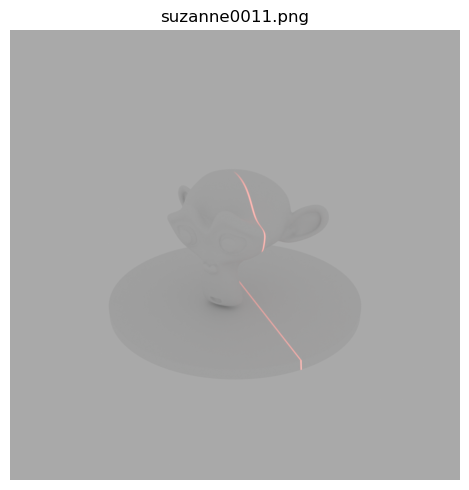

In [5]:
render_dir  = ROOT / paths["input_dir"]
render_glob = paths.get("input_glob", "scan_*.png")
renders     = sorted(render_dir.glob(render_glob))
n_frames    = config["disk"]["n_frames"]

print(f"render dir: {render_dir}")
print(f"render glob: {render_glob}")
print(f"frames:     {len(renders)} / {n_frames}")

assert renders, f"No rendered frames found in {render_dir}"

frame = min(10, len(renders) - 1)
image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(renders[frame].name)
plt.axis("off")
plt.tight_layout()


## 2. Laser Stripe Extraction

masks:  360
coords: 360
stripe points per frame: min 123  mean 250.2  max 279


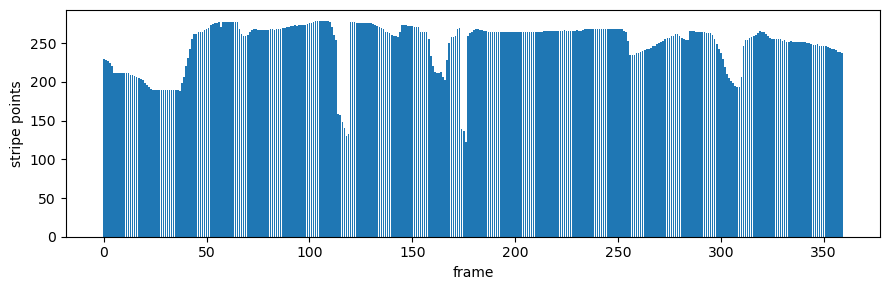

In [6]:
subprocess.run([sys.executable, "extract_stripes.py"], cwd=ROOT, check=True)

mask_glob  = render_glob
coord_glob = Path(render_glob).stem + ".npy"
masks  = sorted((ROOT / paths["stripe_masks_dir"]).glob(mask_glob))
coords = sorted((ROOT / paths["stripe_coords_dir"]).glob(coord_glob))
counts = np.array([len(np.load(path)) for path in coords])

print(f"masks:  {len(masks)}")
print(f"coords: {len(coords)}")
print(f"stripe points per frame: min {counts.min()}  mean {counts.mean():.1f}  max {counts.max()}")

plt.figure(figsize=(9, 3))
plt.bar(range(len(counts)), counts)
plt.xlabel("frame")
plt.ylabel("stripe points")
plt.tight_layout()


## 3. Centerline Check

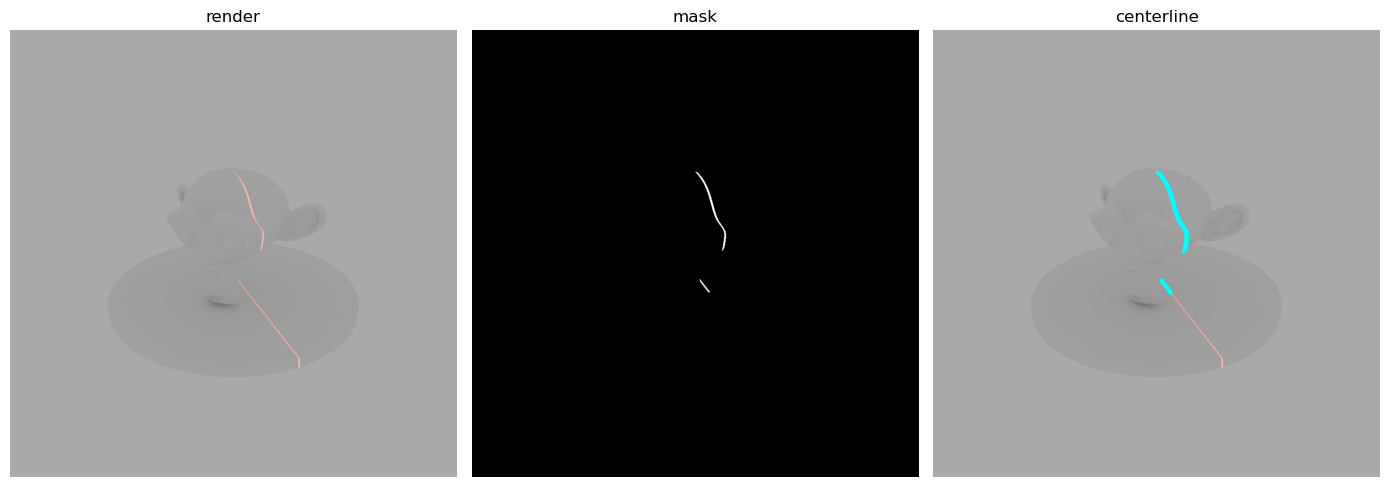

In [7]:
frame = min(10, len(renders) - 1)

image      = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)
mask       = cv2.imread(str(masks[frame]), cv2.IMREAD_GRAYSCALE)
centerline = np.load(coords[frame])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("render")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("mask")
axes[2].imshow(image)
axes[2].scatter(centerline[:, 1], centerline[:, 0], s=3, c="cyan")
axes[2].set_title("centerline")

for ax in axes:
    ax.axis("off")

plt.tight_layout()


## 4. Point Cloud Reconstruction

In [8]:
points = reconstruct_module.reconstruct(config)
point_cloud_path = ROOT / paths["point_cloud"]
reconstruct_module.save_ply(points, point_cloud_path)

print(f"points: {len(points)}")
print(f"saved:  {point_cloud_path}")
print(f"min:    {points.min(axis=0)}")
print(f"max:    {points.max(axis=0)}")
print(f"mean:   {points.mean(axis=0)}")

plot_points(points, "reconstructed point cloud")


points: 74825
saved:  c:\Users\pb00441\ComputerVision\point_cloud_suzanne.ply
min:    [-0.83142793 -0.8185354   0.12002083]
max:    [1.1515896  0.87097687 1.6892154 ]
mean:   [-0.02871474 -0.04673178  1.2038852 ]


radius p05/p50/p95: [0.15815033 0.55090177 0.75858051]
z      p05/p50/p95: [0.33584095 1.28825283 1.66806793]


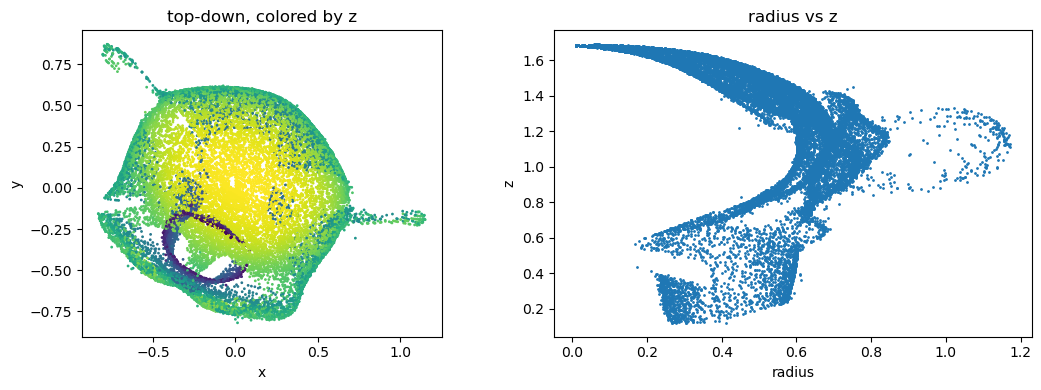

In [9]:
r_xy = np.linalg.norm(points[:, :2], axis=1)
print(f"radius p05/p50/p95: {np.percentile(r_xy, [5, 50, 95])}")
print(f"z      p05/p50/p95: {np.percentile(points[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx    = np.random.default_rng(1).choice(len(points), min(20000, len(points)), replace=False)
sample = points[idx]
axes[0].scatter(sample[:, 0], sample[:, 1], c=sample[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("top-down, colored by z")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(r_xy[idx], sample[:, 2], s=1)
axes[1].set_title("radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()


gt radius p05/p50/p95: [0.52018104 1.47951805 2.00857087]
gt z      p05/p50/p95: [-0.81724014  0.16300009  0.80055255]


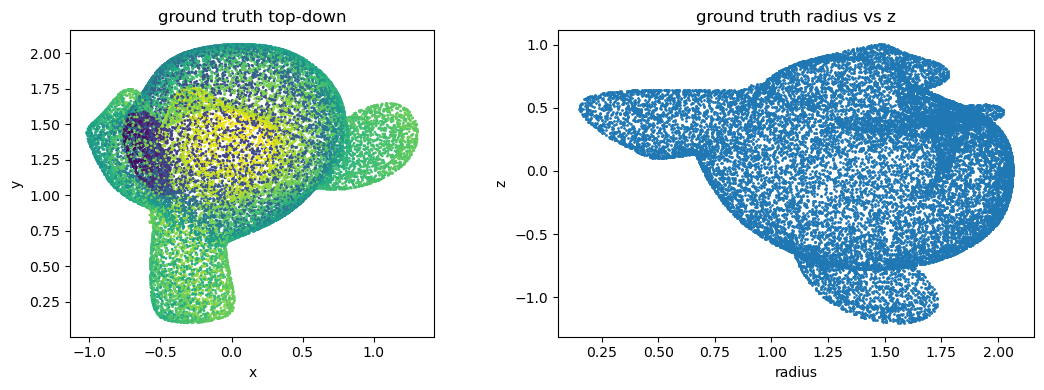

In [10]:
gt_mesh_for_shape = o3d.io.read_triangle_mesh(str(ROOT / paths["ground_truth_mesh"]))
gt_sample_shape   = np.asarray(
    gt_mesh_for_shape.sample_points_uniformly(number_of_points=60000).points
)

gt_radius = np.linalg.norm(gt_sample_shape[:, :2], axis=1)
print(f"gt radius p05/p50/p95: {np.percentile(gt_radius, [5, 50, 95])}")
print(f"gt z      p05/p50/p95: {np.percentile(gt_sample_shape[:, 2], [5, 50, 95])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx_gt  = np.random.default_rng(2).choice(
    len(gt_sample_shape), min(20000, len(gt_sample_shape)), replace=False
)
gt_plot = gt_sample_shape[idx_gt]
axes[0].scatter(gt_plot[:, 0], gt_plot[:, 1], c=gt_plot[:, 2], s=1, cmap="viridis")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("ground truth top-down")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].scatter(gt_radius[idx_gt], gt_plot[:, 2], s=1)
axes[1].set_title("ground truth radius vs z")
axes[1].set_xlabel("radius")
axes[1].set_ylabel("z")
plt.tight_layout()


## 5. Reconstruction

Poisson (5a), volumetric SDF with winding number sign (5b), and neural implicit / IGR (5c).


### 5a. Poisson

In [11]:
importlib.reload(reconstruct_module)

cam_location  = config["camera"].get("location", None)
recon_base    = ROOT / paths["reconstructed_mesh"]

mesh_path_poisson = recon_base.with_name(recon_base.stem + "_poisson" + recon_base.suffix)
mesh_obj_poisson  = mesh_path_poisson.with_suffix(".obj")

mesh_poisson = reconstruct_module.reconstruct_surface(
    points, str(mesh_path_poisson), camera_location=cam_location
)
reconstruct_module.export_mesh(mesh_poisson, str(mesh_obj_poisson))

print(f"vertices: {len(mesh_poisson.vertices)}  triangles: {len(mesh_poisson.triangles)}")
plot_mesh(mesh_poisson, "Poisson")


[Open3D WARNING] Write OBJ can not include triangle normals.
vertices: 145339  triangles: 288624


### 5b. SDF

Volumetric SDF + Gaussian smoothing + marching cubes.
Sign uses a 1/d^3 winding-number approximation over the k nearest surface points -- no extra libraries needed.

| param | effect |
|---|---|
| `voxel_resolution` | grid size -- higher = more detail |
| `smooth_sigma` | Gaussian sigma -- higher = smoother |
| `k_sign` | neighbours for winding-number vote (16 is a good default) |


In [12]:
importlib.reload(reconstruct_module)

cam_location = config["camera"].get("location", None)
recon_base   = ROOT / paths["reconstructed_mesh"]

mesh_path_sdf = recon_base
mesh_obj_sdf  = mesh_path_sdf.with_suffix(".obj")

voxel_resolution = 128
smooth_sigma     = 1.5
k_sign           = 16  # winding-number neighbours; 16 gives robust sign near thin features

mesh_sdf = reconstruct_module.reconstruct_surface_sdf(
    points, str(mesh_path_sdf),
    voxel_resolution=voxel_resolution, smooth_sigma=smooth_sigma, k_sign=k_sign,
    camera_location=cam_location,
)
reconstruct_module.export_mesh(mesh_sdf, str(mesh_obj_sdf))

print(f"vertices: {len(mesh_sdf.vertices)}  triangles: {len(mesh_sdf.triangles)}")
plot_mesh(mesh_sdf, f"SDF (res={voxel_resolution}, sigma={smooth_sigma})")


[Open3D WARNING] Write OBJ can not include triangle normals.
vertices: 53867  triangles: 107218


### 5c. Neural implicit (IGR)

Fits a 6-layer MLP directly to the point cloud via surface + Eikonal losses -- no pretrained weights needed.
GPU recommended; CPU takes ~5-10 min. For a fully pretrained variant see [Points2Surf](https://github.com/ErlerPhilipp/points2surf).


In [13]:
importlib.reload(reconstruct_module)

cam_location = config["camera"].get("location", None)
recon_base   = ROOT / paths["reconstructed_mesh"]

mesh_path_neural = recon_base.with_name(recon_base.stem + "_neural" + recon_base.suffix)
mesh_obj_neural  = mesh_path_neural.with_suffix(".obj")

# iterations: more = better quality but slower (2000 is ~5-10 min on CPU, ~1 min on GPU)
iterations       = 2000
voxel_resolution = 128
smooth_sigma     = 0.8

mesh_neural = reconstruct_module.reconstruct_surface_neural(
    points, str(mesh_path_neural),
    voxel_resolution=voxel_resolution, smooth_sigma=smooth_sigma, iterations=iterations,
    camera_location=cam_location,
)
reconstruct_module.export_mesh(mesh_neural, str(mesh_obj_neural))

print(f"vertices: {len(mesh_neural.vertices)}  triangles: {len(mesh_neural.triangles)}")
plot_mesh(mesh_neural, f"Neural IGR (iters={iterations}, sigma={smooth_sigma})")


OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\pb00441\AppData\Local\miniconda3\envs\ccit_bz\lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

## 6. Chamfer Distance Comparison

Computes symmetric Chamfer distance for each method against the ground truth mesh.


{
  "reconstruction_to_ground_truth_mean": 0.23182827215997998,
  "ground_truth_to_reconstruction_mean": 0.08791787001635941,
  "chamfer_l1_mean": 0.1598730710881697,
  "chamfer_l2_mean": 0.05992843832176205,
  "reconstruction_to_ground_truth_p95": 0.7427252115258185,
  "ground_truth_to_reconstruction_p95": 0.21657853848263806,
  "dataset": "suzanne",
  "sample_count": 30000,
  "ground_truth_aligned_by_centroid_scale": true,
  "ground_truth_aligned_by_scaling_icp": true
}
saved: c:\Users\pb00441\ComputerVision\metrics_suzanne.json


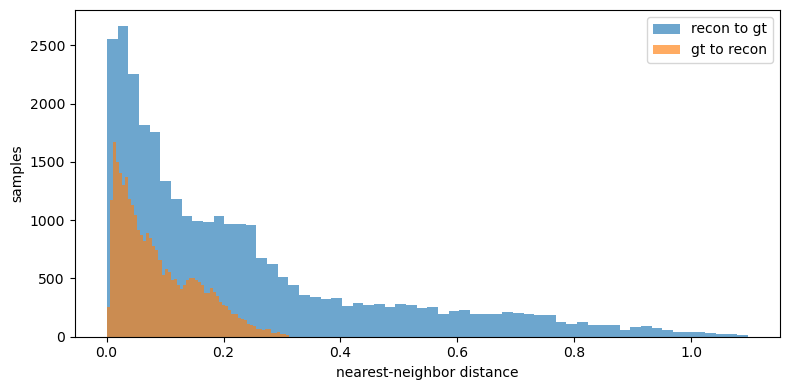

In [ ]:
ground_truth_path = ROOT / paths["ground_truth_mesh"]
sample_count      = 30000
recon_base        = ROOT / paths["reconstructed_mesh"]

candidates = {
    "Poisson": recon_base.with_name(recon_base.stem + "_poisson" + recon_base.suffix),
    "SDF":     recon_base,
    "Neural":  recon_base.with_name(recon_base.stem + "_neural" + recon_base.suffix),
}

if not ground_truth_path.exists():
    print(f"Ground truth mesh not found: {ground_truth_path}")
else:
    o3d.utility.random.seed(42)
    gt_sample = reconstruct_module.sample_mesh(str(ground_truth_path), sample_count)

    results = {}
    for method, mp in candidates.items():
        if not mp.exists():
            print(f"{method}: mesh not found, skipping")
            continue
        recon_s = reconstruct_module.sample_mesh(str(mp), sample_count)
        gt_a    = reconstruct_module.align_by_centroid_scale(gt_sample, recon_s)
        gt_a    = reconstruct_module.align_by_icp(gt_a, recon_s)
        d_r2g   = np.asarray(recon_s.compute_point_cloud_distance(gt_a))
        d_g2r   = np.asarray(gt_a.compute_point_cloud_distance(recon_s))
        results[method] = (d_r2g, d_g2r)
        chamfer = (d_r2g.mean() + d_g2r.mean()) / 2
        print(f"{method:10s}  chamfer={chamfer:.5f}  r->gt={d_r2g.mean():.5f}  gt->r={d_g2r.mean():.5f}")

    if results:
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
        if len(results) == 1:
            axes = [axes]
        for ax, (method, (d_r2g, d_g2r)) in zip(axes, results.items()):
            ax.hist(d_r2g, bins=50, alpha=0.65, label="recon to gt")
            ax.hist(d_g2r, bins=50, alpha=0.65, label="gt to recon")
            ax.set_title(method)
            ax.set_xlabel("distance")
            ax.legend()
        axes[0].set_ylabel("samples")
        plt.tight_layout()
